<a href="https://colab.research.google.com/github/Jason111-poxie/cloud_classification_project/blob/main/Spatial%20data%20analysis%20poject%20for%20Victoria%20State.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rainfall, Elevation and Agricultural Production Value in Victoria

## Topic
Environmental and agricultural spatial analysis.

## Research Question
How do rainfall variation and elevation relate to the spatial distribution of agricultural production value across Victorian LGAs?


## Study Area and Scope
Study area is Victoria, Australia. Spatial unit of analysis is the Local Government Area (LGA) allowing for aggregation of agricultural production value, rainfall, elevation and weather station data to compare across regions. Time scope is 2020–21 financial year, matched to agricultural production value dataset. Rainfall data July 2020–June 2021 used to represent rainfall conditions during same financial year.

## Data Sources and Analytical Role

| Dataset | Data Type | Source | Role in Analysis |
|---|---|---|---|
| ABS Local Government Area Boundaries 2021 | Polygon | Australian Bureau of Statistics, ASGS Edition 3 | Main spatial unit for analysis. Victorian LGAs are used to summarise and compare all variables. |
| ABS States and Territories Boundary 2021 | Polygon | Australian Bureau of Statistics, ASGS Edition 3 | Used to identify and isolate Victoria as the study area. |
| Agricultural Value by LGA 2020–21 | Attribute table | Australian Bureau of Statistics, Value of Agricultural Commodities Produced | Represents agricultural production value as the main outcome variable. |
| BoM Weather Stations | Point | Bureau of Meteorology Climate Data Online | Used to show the spatial distribution of rainfall observation stations and count station coverage by LGA. |
| SILO Monthly Rainfall Rasters, July 2020–June 2021 | Raster | SILO / LongPaddock gridded climate data | Used to estimate annual rainfall for each Victorian LGA using zonal statistics. |
| SRTM 30 m Digital Elevation Model | Raster | Geoscience Australia / SRTM-derived elevation data | Used to estimate mean elevation for each Victorian LGA using zonal statistics. |

# Literature Review

Agriculture in Victoria varies a lot from one local government area to another. Some areas are mainly used for cropping, while others have more livestock, dairy, horticulture or mixed farming. These differences are not only related to the economy, but also to the physical environment of each region. Climate, landform, soil conditions and land use all affect what type of farming can take place in an area (Department of Energy, Environment and Climate Action, n.d.; Hughes et al., 2017). Because of this, mapping agricultural production value by LGA can help show where agricultural activity is concentrated and where values are lower.

Rainfall is included because it is directly related to water availability for crops and pasture. In Victoria, not all farming areas have the same access to irrigation, so rainfall can still be an important background condition for agriculture. Rainfall in Australia also changes a lot between regions and from year to year, and dry periods can reduce farm output and income (Hughes et al., 2017). This is relevant to southern and south-eastern Australia, where many farming systems still rely on seasonal rainfall (Bureau of Meteorology & CSIRO, 2024; Hughes et al., 2022). Therefore, rainfall is useful for checking whether wetter or drier LGAs show different levels of agricultural production value.

Elevation is used as a simple terrain variable. It does not fully describe land suitability, but it gives some indication of differences in landscape conditions. Higher areas may be cooler or steeper, which can affect drainage, erosion risk, soil development and the types of farming that are suitable. Lower and flatter areas may be easier to use for cropping or more intensive agriculture, although water access and soil quality are also important. For this reason, elevation is included to provide extra context when comparing agricultural production value across Victorian LGAs (Department of Energy, Environment and Climate Action, n.d.; Geoscience Australia, 2025).

This project does not claim that rainfall and elevation are the main causes of agricultural production value. Agricultural value is also shaped by irrigation, commodity prices, farm size, farming type, technology and management decisions (Chancellor et al., 2021; Hughes et al., 2017). The purpose of this project is more limited: to explore whether rainfall and elevation show any relationship with agricultural production value across Victorian LGAs, and whether these environmental variables help explain some of the differences shown on the maps.

## Methodology overview

We use the Victorian LGAs as our common spatial unit. First, we clean the ABS agri value table and join it to the LGA boundary layer using LGA codes (Australian Bureau of Statistics, 2021, 2022). Second, BoM weather stations are point data and counted up within each LGA using a spatial join (Bureau of Meteorology, n.d.). Third, rainfall and elevation are treated as raster data and zonal stats used to get mean rainfall and mean elevation for each LGA (SILO, n.d.; Jeffrey et al., 2001; Geoscience Australia, n.d.). After combining these variables into one LGA level table, I use ESDA to look at distributions, rankings, spatial patterns and simple relationships between variables.

My own analysis then classifies LGAs into interesting groupings based on relative thresholds of agri value, rainfall and elevation. It’s not meant to prove causality, just help identify different regional patterns – like higher value agri LGAs with less rainfall, or low-value LGAs in higher elevations.

## 1. Import libraries and set paths

This cell imports the libraries and sets the data paths.

In [ ]:
from pathlib import Path
import re
import os
import warnings

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio
from rasterio.enums import Resampling
from rasterstats import zonal_stats

pd.options.mode.chained_assignment = None
plt.rcParams["figure.dpi"] = 120

In [ ]:
data = Path("data")

bdir = data / "boundaries"
adir = data / "agriculture"
cdir = data / "climate"
sdir = data / "stations"
edir = data / "elevation"

ste_path = bdir / "STE_2021_AUST_GDA2020.shp"
ag_path = adir / "agri_value_lga_2020_21.xlsx"
st_path = sdir / "stations.txt"
dem_path = edir / "victoria_dem_srtm30.tif"

lga_path = list(bdir.rglob("LGA_2021_AUST_GDA2020.shp"))[0]

## 2. Read boundary data

The LGA boundary is the main polygon layer, and Victoria is used as the study area.

In [ ]:
ste = gpd.read_file(ste_path)
lga = gpd.read_file(lga_path)

vic = ste[ste["STE_NAME21"] == "Victoria"].copy()
v_lga = lga[lga["STE_NAME21"] == "Victoria"].copy()

print("State CRS:", vic.crs)
print("LGA CRS:", v_lga.crs)
print("Victorian LGAs:", len(v_lga))

v_lga[["LGA_CODE21", "LGA_NAME21", "STE_NAME21"]].head()

State CRS: EPSG:7844
LGA CRS: EPSG:7844
Victorian LGAs: 82


,LGA_CODE21,LGA_NAME21,STE_NAME21
131,20110,Alpine,Victoria
132,20260,Ararat,Victoria
133,20570,Ballarat,Victoria
134,20660,Banyule,Victoria
135,20740,Bass Coast,Victoria


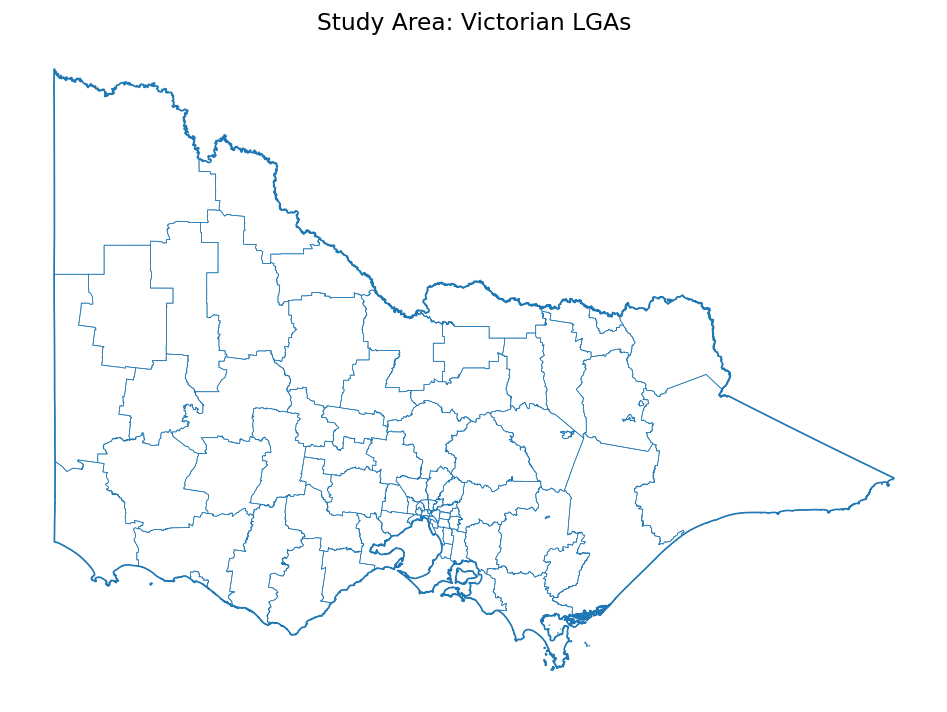

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

v_lga.boundary.plot(ax=ax, linewidth=0.4)
vic.boundary.plot(ax=ax, linewidth=1.0)

ax.set_title("Study Area: Victorian LGAs", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("map_study_area_victoria.png", dpi=300, bbox_inches="tight")
plt.show()

The study area map confirms that the analysis is limited to Victoria. The LGA boundaries are used as the main spatial framework because the agricultural production value data are reported at LGA level. This means the results should be interpreted as regional summaries rather than farm-level or property-level conditions.

## 3. Clean agricultural value data

The purpose of step three is to clean the ABS Agricultural Value table data to prepare it for spatial analysis. This data is found on several different sheets (and has multiple header rows); therefore, the code will first identify the LGA level data and then extract the total and then clean and convert to numeric for joining to the LGA boundary layer.

In [ ]:
xls = pd.ExcelFile(ag_path)

hit = []

for sh in xls.sheet_names:
    tmp = pd.read_excel(ag_path, sheet_name=sh, header=None)
    m = tmp.apply(
        lambda x: x.astype(str).str.contains("Region code", case=False, na=False).any(),
        axis=1
    )
    if m.sum() > 0:
        hit.append((sh, m[m].index[0], tmp.shape))

if len(hit) == 0:
    raise ValueError("Could not find the agricultural data sheet containing Region code.")

sh = hit[0][0]
row = hit[0][1]

ag = pd.read_excel(ag_path, sheet_name=sh, header=row)
ag = ag.dropna(how="all")
ag.columns = [str(x).strip() for x in ag.columns]

print("Sheet used:", sh)
print("Header row:", row)
print("Rows:", len(ag))
ag.head()

Sheet used: Table 1
Header row: 6
Rows: 16067


,Region code,Region label,Commodity code,Commodity description,Gross value ($),Local value ($)
0,0,Australia,1500158.0,Broadacre crops - Cereal crops - Wheat for grain,9.850955e+09,9.108583e+09
1,0,Australia,1500858.0,Broadacre crops - Cereal crops - Oats for grain,5.414716e+08,4.965480e+08
2,0,Australia,1501758.0,Broadacre crops - Cereal crops - Barley for grain,3.728468e+09,3.412769e+09
3,0,Australia,1504158.0,Broadacre crops - Cereal crops - Sorghum for g...,5.397594e+08,4.895469e+08
4,0,Australia,1508558.0,Broadacre crops - Cereal crops - Rice for grain,1.743894e+08,1.513367e+08


In [ ]:
code_col = [x for x in ag.columns if "Region code" in x][0]
name_col = [x for x in ag.columns if "Region label" in x][0]
item_col = [x for x in ag.columns if "Commodity description" in x][0]
val_col = [x for x in ag.columns if "Local value" in x][0]

ag["code"] = (
    ag[code_col]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
    .str.zfill(5)
)

ag["area"] = ag[name_col].astype(str).str.strip()
ag["item"] = ag[item_col].astype(str).str.strip()

ag["val"] = (
    ag[val_col]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
)

ag["val"] = pd.to_numeric(ag["val"], errors="coerce")

tag = ag[ag["item"].str.lower().str.contains("total", na=False)].copy()

tag[["code", "area", "item", "val"]].head()

,code,area,item,val
16,00000,Australia,Broadacre crops - Total,2.149822e+10
17,00000,Australia,Hay - Total,2.160429e+09
20,00000,Australia,"Nurseries, cut flowers or cultivated turf - Nu...",1.224821e+09
23,00000,Australia,"Nurseries, cut flowers or cultivated turf - Cu...",2.024987e+08
25,00000,Australia,"Nurseries, cut flowers or cultivated turf - Total",1.702213e+09


## 4. Join agricultural value to LGAs

This cell joins agricultural value to the Victorian LGA layer by LGA code.

In [ ]:
ag2 = (
    tag
    .groupby("code", as_index=False)["val"]
    .max()
    .rename(columns={"val": "ag_val"})
)

v_lga["code"] = v_lga["LGA_CODE21"].astype(str)

g = v_lga.merge(
    ag2,
    on="code",
    how="left"
)

g["ag_val"] = pd.to_numeric(g["ag_val"], errors="coerce")

print("Agricultural value matched:", g["ag_val"].notna().sum(), "/", len(g))
g[["LGA_NAME21", "ag_val"]].sort_values("ag_val", ascending=False).head(10)

Agricultural value matched: 73 / 82


,LGA_NAME21,ag_val
45,Mildura,1.071449e+09
54,Moyne,9.332817e+08
16,Corangamite,8.868281e+08
11,Campaspe,7.385551e+08
66,Swan Hill,7.049376e+08
70,Wellington,6.860773e+08
47,Moira,6.775808e+08
27,Greater Shepparton,6.712619e+08
61,South Gippsland,6.233024e+08
78,Yarriambiack,5.701953e+08


## 5. Point data analysis: weather stations by LGA

In this project we will be using BoM’s weather stations (the point dataset) and first filtering out all of Victoria and then use a Spatial Join to count the number of stations per LGA. We will then be using the station count to describe the spatial coverage of climate observation points, not as an explanation of agricultural production value.

In [ ]:
rows = []
pat = re.compile(
    r"^(\d{6})\s+(\d{2})\s+(.+?)\s+(\d{4})\s+(\d{4}|\.\.)\s+"
    r"(-?\d+\.\d+)\s+(-?\d+\.\d+)\s+(\S+)\s+([A-Z]{2,3})\s+([-\d\.]+|\.\.)"
)

with open(st_path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        m = pat.match(line)
        if m:
            rows.append({
                "id": m.group(1),
                "dist": m.group(2),
                "name": m.group(3).strip(),
                "start": m.group(4),
                "end": m.group(5),
                "lat": float(m.group(6)),
                "lon": float(m.group(7)),
                "src": m.group(8),
                "state": m.group(9),
                "height": np.nan if m.group(10) == ".." else float(m.group(10))
            })

st = pd.DataFrame(rows)

st = gpd.GeoDataFrame(
    st,
    geometry=gpd.points_from_xy(st["lon"], st["lat"]),
    crs="EPSG:4326"
)

print("Stations parsed:", len(st))
st.head()

Stations parsed: 16276


,id,dist,name,start,end,lat,lon,src,state,height,geometry
0,001000,01,KARUNJIE,1940,1983,-16.2919,127.1956,.....,WA,320.0,POINT (127.1956 -16.2919)
1,001001,01,OOMBULGURRI,1914,2012,-15.1806,127.8456,GPS,WA,2.0,POINT (127.8456 -15.1806)
2,001002,01,BEVERLEY SP,1959,1967,-16.5825,125.4828,.....,WA,NaN,POINT (125.4828 -16.5825)
3,001003,01,PAGO MISSION,1908,1940,-14.1331,126.7158,.....,WA,5.0,POINT (126.7158 -14.1331)
4,001004,01,KUNMUNYA,1915,1948,-15.4167,124.7167,.....,WA,47.0,POINT (124.7167 -15.4167)


In [ ]:
vic2 = vic.to_crs("EPSG:4326")
g2 = g.to_crs("EPSG:4326")

v_st = gpd.sjoin(
    st,
    vic2[["geometry"]],
    how="inner",
    predicate="within"
)

v_st2 = v_st.drop(columns=["index_right"], errors="ignore").copy()

st_lga = gpd.sjoin(
    v_st2,
    g2[["LGA_CODE21", "LGA_NAME21", "geometry"]],
    how="inner",
    predicate="within"
)

cnt = (
    st_lga
    .groupby("LGA_CODE21")
    .size()
    .reset_index(name="st_cnt")
)

g = g.drop(columns=["st_cnt"], errors="ignore")
g = g.merge(cnt, on="LGA_CODE21", how="left")
g["st_cnt"] = g["st_cnt"].fillna(0).astype(int)

print("Stations in Victoria:", len(v_st2))
g[["LGA_NAME21", "st_cnt"]].sort_values("st_cnt", ascending=False).head(10)

Stations in Victoria: 2433


,LGA_NAME21,st_cnt
18,East Gippsland,176
70,Wellington,111
45,Mildura,88
5,Baw Baw,84
77,Yarra Ranges,82
61,South Gippsland,76
37,Loddon,67
10,Buloke,59
66,Swan Hill,55
71,West Wimmera,52


In [ ]:
st_sum = pd.DataFrame({
    "measure": [
        "Stations parsed from source file",
        "Stations located within Victoria",
        "Victorian LGAs with at least one station",
        "Victorian LGAs with no station"
    ],
    "value": [
        len(st),
        len(v_st2),
        (g["st_cnt"] > 0).sum(),
        (g["st_cnt"] == 0).sum()
    ]
})

st_sum

,measure,value
0,Stations parsed from source file,16276
1,Stations located within Victoria,2433
2,Victorian LGAs with at least one station,80
3,Victorian LGAs with no station,2


The summary table shows how we turned our point dataset into an LGA-level variable. It helps make the point data comparable with the polygon-based agricultural value and the raster-derived rainfall and elevation variables

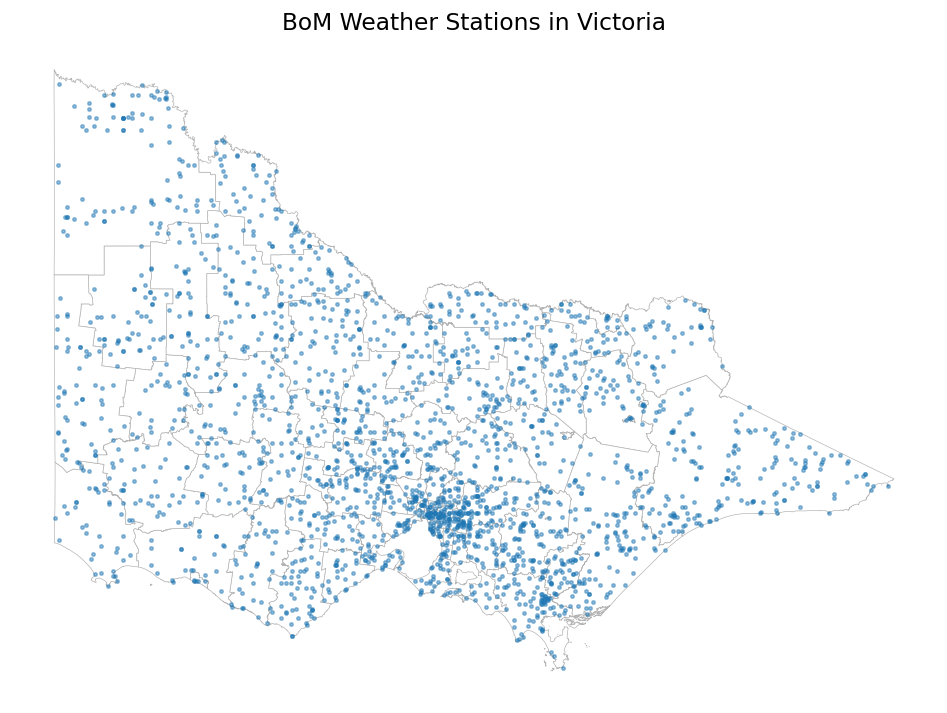

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

g.to_crs("EPSG:4326").plot(
    ax=ax,
    color="white",
    edgecolor="0.7",
    linewidth=0.4
)

v_st2.plot(
    ax=ax,
    markersize=4,
    alpha=0.45
)

ax.set_title("BoM Weather Stations in Victoria", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("map_weather_stations_victoria.png", dpi=300, bbox_inches="tight")
plt.show()

The station map shows that weather stations are not evenly distributed. They are generally denser around more settled and accessible areas. This is important because station observations are part of the wider climate data context, but the LGA rainfall values in the next step come from a continuous raster surface rather than from station counts alone.

## 6. Create rainfall raster

This cell combines the 12 monthly rainfall rasters into one 2020–21 rainfall raster.

In [ ]:
rdir = cdir / "2020_21_monthly_rain"

rain_out = cdir / "rain_2020_21_total.tif"
rain_files = sorted(rdir.glob("20*.monthly_rain.tif"))

print("Monthly rainfall files:", len(rain_files))

s = None
n = None
prof = None

for f in rain_files:
    with rasterio.open(f) as src:
        a = src.read(1).astype("float32")

        bad = np.zeros(a.shape, dtype=bool)

        if src.nodata is not None:
            bad = bad | (a == src.nodata)

        bad = bad | (a < 0) | np.isnan(a)

        if s is None:
            s = np.zeros(a.shape, dtype="float32")
            n = np.zeros(a.shape, dtype="int16")
            prof = src.profile.copy()

        ok = ~bad
        s[ok] += a[ok]
        n[ok] += 1

out_arr = s.copy()
out_arr[n == 0] = -9999

prof.update(dtype="float32", nodata=-9999)

with rasterio.open(rain_out, "w", **prof) as dst:
    dst.write(out_arr, 1)

print("Rainfall raster:", rain_out)

Monthly rainfall files: 12
Rainfall raster: data\climate\rain_2020_21_total.tif


The 12 monthly rainfall rasters were combined into one total rainfall raster for the 2020–21 financial year. This raster is not used as a final map by itself. Instead, it is used in the next step to calculate mean rainfall for each Victorian LGA.

## 7. Mean rainfall by LGA

Using zonal statistics, the rainfall raster will be summarized by Local Government Area (LGA) polygon. Since there can be many rainfall raster cells within a single LGA, an average value will be calculated from these cells (i.e., the mean) to create one rainfall variable for each LGA. This will allow for comparisons between the agricultural value and the respective rainfall values at the same scale.

In [ ]:
with rasterio.open(rain_out) as src:
    r_crs = src.crs

g["rain"] = pd.Series(np.nan, index=g.index, dtype="float64")

r_lga = g.to_crs(r_crs).copy()
ok = r_lga.geometry.notna() & (~r_lga.geometry.is_empty)

zs = zonal_stats(
    list(r_lga.loc[ok, "geometry"]),
    rain_out,
    stats=["mean"],
    nodata=-9999
)

vals = [np.nan if x["mean"] is None else float(x["mean"]) for x in zs]
g.loc[ok, "rain"] = np.array(vals, dtype="float64")
g["rain"] = pd.to_numeric(g["rain"], errors="coerce")

print("Rainfall values:", g["rain"].notna().sum(), "/", len(g))
g[["LGA_NAME21", "rain"]].sort_values("rain", ascending=False).head(10)

Rainfall values: 78 / 82


,LGA_NAME21,rain
77,Yarra Ranges,1357.202972
5,Baw Baw,1273.489615
0,Alpine,1184.700507
79,Unincorporated Vic,1071.981800
67,Towong,1040.207481
61,South Gippsland,1024.715718
12,Cardinia,1024.567954
18,East Gippsland,1019.714734
15,Colac Otway,1017.856404
40,Mansfield,1016.448718


Mean rainfall was calculated for most Victorian LGAs. The highest values appear in wetter eastern and upland areas, including Yarra Ranges, Baw Baw, Alpine, South Gippsland and East Gippsland. In contrast, north-western LGAs such as Mildura and Swan Hill have much lower rainfall. This creates a useful environmental variable for comparing rainfall with agricultural value.

## 8. Mean elevation by LGA

Using the same approach as with zonal statistics for the DEM, this step will calculate the mean elevation for each LGA, producing a terrain variable that is then able to be compared against rainfall and agricultural value. While mean elevation is a simple indicator about terrain, it should be viewed as a broad regional context for suitability of terrain, rather than providing an exact measure.

In [ ]:
with rasterio.open(dem_path) as src:
    d_crs = src.crs
    d_nodata = src.nodata

g["elev"] = np.nan

e_lga = g[["LGA_CODE21", "LGA_NAME21", "geometry"]].copy()
e_lga = e_lga[e_lga.geometry.notna()].copy()
e_lga = e_lga[~e_lga.geometry.is_empty].copy()
e_lga = e_lga.to_crs(d_crs)

zs = zonal_stats(
    list(e_lga.geometry),
    dem_path,
    stats=["mean"],
    nodata=d_nodata
)

e = pd.Series(
    [x["mean"] for x in zs],
    index=e_lga.index
)

g.loc[e.index, "elev"] = e
g["elev"] = pd.to_numeric(g["elev"], errors="coerce")

print("elev values:", g["elev"].notna().sum(), "/", len(g))

g[["LGA_NAME21", "elev"]].dropna().sort_values("elev", ascending=False).head(10)

elev values: 80 / 82


,LGA_NAME21,elev
0,Alpine,823.999012
40,Mansfield,679.441632
67,Towong,653.411143
79,Unincorporated Vic,549.862504
38,Macedon Ranges,506.295178
18,East Gippsland,505.981896
77,Yarra Ranges,492.368887
28,Hepburn,490.980004
55,Murrindindi,487.441786
50,Moorabool,442.731365


Mean elevation was calculated for each Victorian LGA from the DEM. This creates an elevation variable that can be compared with agricultural value and rainfall in the later ESDA and map sections. Higher mean elevation is expected in eastern and north-eastern LGAs, such as Alpine and Mansfield, while lower elevation is more common in flatter western and north-western LGAs.

## 9. ESDA: summary and top LGAs

This cell shows summary statistics and the top LGAs for the main variables.

In [ ]:
g["ag_val"] = pd.to_numeric(g["ag_val"], errors="coerce")
g["rain"] = pd.to_numeric(g["rain"], errors="coerce")
g["elev"] = pd.to_numeric(g["elev"], errors="coerce")
g["st_cnt"] = pd.to_numeric(g["st_cnt"], errors="coerce").fillna(0).astype(int)

g["ag_val_m"] = g["ag_val"] / 1e6

summary = g[["ag_val", "ag_val_m", "rain", "elev", "st_cnt"]].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
ag_val,73.0,2.253528e+08,2.607694e+08,76.700000,1.679721e+07,1.164358e+08,3.381189e+08,1.071449e+09
ag_val_m,73.0,2.253528e+02,2.607694e+02,0.000077,1.679721e+01,1.164358e+02,3.381189e+02,1.071449e+03
rain,78.0,7.004482e+02,2.323449e+02,223.227043,5.682063e+02,6.887739e+02,8.364959e+02,1.357203e+03
elev,80.0,1.947198e+02,1.788058e+02,7.797809,6.561716e+01,1.199588e+02,2.646644e+02,8.239990e+02
st_cnt,82.0,2.967073e+01,2.830742e+01,0.000000,8.000000e+00,2.650000e+01,4.250000e+01,1.760000e+02


In [ ]:
top_ag = (
    g[["LGA_NAME21", "ag_val", "rain", "elev", "st_cnt"]]
    .dropna(subset=["ag_val"])
    .sort_values("ag_val", ascending=False)
    .head(10)
)

top_ag

,LGA_NAME21,ag_val,rain,elev,st_cnt
45,Mildura,1.071449e+09,230.969265,64.258415,88
54,Moyne,9.332817e+08,795.862808,113.339008,30
16,Corangamite,8.868281e+08,840.255556,145.655845,35
11,Campaspe,7.385551e+08,396.375939,116.888298,46
66,Swan Hill,7.049376e+08,223.227043,67.832140,55
70,Wellington,6.860773e+08,938.345298,366.501823,111
47,Moira,6.775808e+08,445.846084,118.410449,44
27,Greater Shepparton,6.712619e+08,433.969291,121.507111,30
61,South Gippsland,6.233024e+08,1024.715718,117.917171,76
78,Yarriambiack,5.701953e+08,293.282044,101.331786,50


In [ ]:
top_rain = (
    g[["LGA_NAME21", "rain", "ag_val", "elev", "st_cnt"]]
    .dropna(subset=["rain"])
    .sort_values("rain", ascending=False)
    .head(10)
)

top_rain

,LGA_NAME21,rain,ag_val,elev,st_cnt
77,Yarra Ranges,1357.202972,3.612726e+08,492.368887,82
5,Baw Baw,1273.489615,4.478974e+08,429.026335,84
0,Alpine,1184.700507,6.836209e+07,823.999012,36
79,Unincorporated Vic,1071.981800,1.008592e+06,549.862504,10
67,Towong,1040.207481,1.507328e+08,653.411143,41
61,South Gippsland,1024.715718,6.233024e+08,117.917171,76
12,Cardinia,1024.567954,3.011362e+08,104.786320,37
18,East Gippsland,1019.714734,2.328494e+08,505.981896,176
15,Colac Otway,1017.856404,2.714314e+08,195.109183,50
40,Mansfield,1016.448718,6.275668e+07,679.441632,29


In [ ]:
top_elev = (
    g[["LGA_NAME21", "elev", "ag_val", "rain", "st_cnt"]]
    .dropna(subset=["elev"])
    .sort_values("elev", ascending=False)
    .head(10)
)

top_elev

,LGA_NAME21,elev,ag_val,rain,st_cnt
0,Alpine,823.999012,6.836209e+07,1184.700507,36
40,Mansfield,679.441632,6.275668e+07,1016.448718,29
67,Towong,653.411143,1.507328e+08,1040.207481,41
79,Unincorporated Vic,549.862504,1.008592e+06,1071.981800,10
38,Macedon Ranges,506.295178,4.742742e+07,786.952799,45
18,East Gippsland,505.981896,2.328494e+08,1019.714734,176
77,Yarra Ranges,492.368887,3.612726e+08,1357.202972,82
28,Hepburn,490.980004,1.015758e+08,767.354545,29
55,Murrindindi,487.441786,1.770389e+08,917.974522,52
50,Moorabool,442.731365,1.552255e+08,831.433775,43


In [ ]:
top_st = (
    g[["LGA_NAME21", "st_cnt", "ag_val", "rain", "elev"]]
    .sort_values("st_cnt", ascending=False)
    .head(10)
)

top_st

,LGA_NAME21,st_cnt,ag_val,rain,elev
18,East Gippsland,176,2.328494e+08,1019.714734,505.981896
70,Wellington,111,6.860773e+08,938.345298,366.501823
45,Mildura,88,1.071449e+09,230.969265,64.258415
5,Baw Baw,84,4.478974e+08,1273.489615,429.026335
77,Yarra Ranges,82,3.612726e+08,1357.202972,492.368887
61,South Gippsland,76,6.233024e+08,1024.715718,117.917171
37,Loddon,67,5.644964e+08,399.002940,141.688809
10,Buloke,59,4.783405e+08,260.143237,98.666970
66,Swan Hill,55,7.049376e+08,223.227043,67.832140
71,West Wimmera,52,4.284001e+08,441.155651,144.409535


Ranking tables make the ESDA more grounded than a general map description. The top agricultural LGAs are not always the wettest or highest LGAs, which shows that rainfall and elevation relate to agricultural value but don’t tell you everything. The station count table adds the point-data component. The purpose of this table is to display those LGAs in Victoria with the most weather stations, so we can determine how well covered the state is in regards to climate observation.

## 10. ESDA: histograms

This cell plots the overall distribution of each of the primary LGA-level variables used in this report, including agricultural value, street level produced rainfall and elevation, and weather station count.

In [ ]:
def hist_plot(col, title, xlabel, out_file):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(g[col].dropna(), bins=20)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of LGAs")
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()

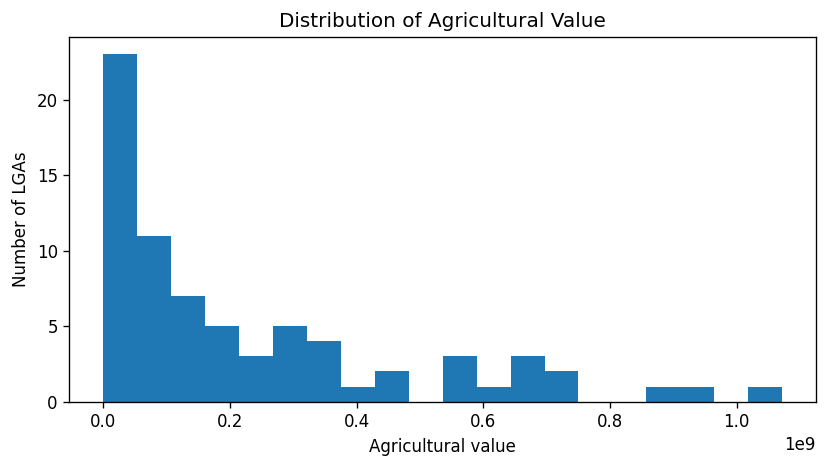

In [ ]:
hist_plot(
    "ag_val",
    "Distribution of Agricultural Value",
    "Agricultural value",
    "hist_agricultural_value.png"
)

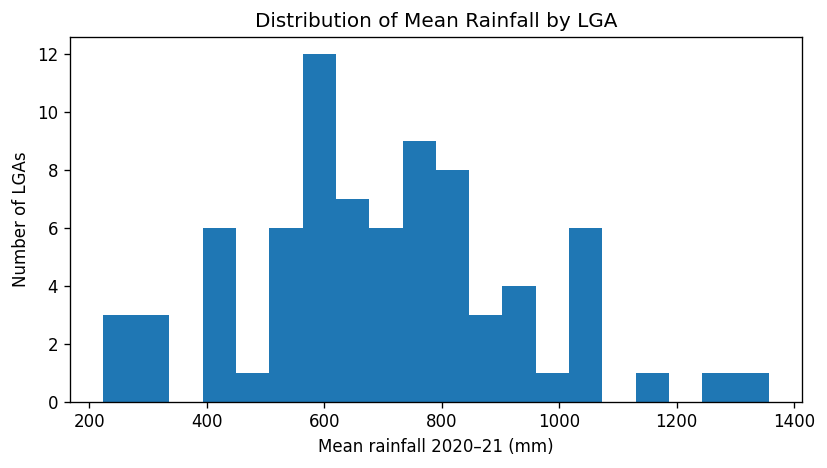

In [ ]:
hist_plot(
    "rain",
    "Distribution of Mean Rainfall by LGA",
    "Mean rainfall 2020–21 (mm)",
    "hist_mean_rainfall.png"
)

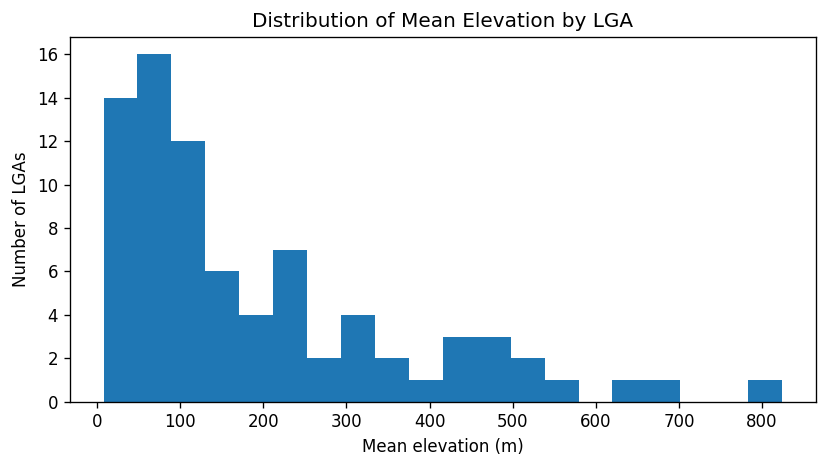

In [ ]:
hist_plot(
    "elev",
    "Distribution of Mean Elevation by LGA",
    "Mean elevation (m)",
    "hist_mean_elevation.png"
)

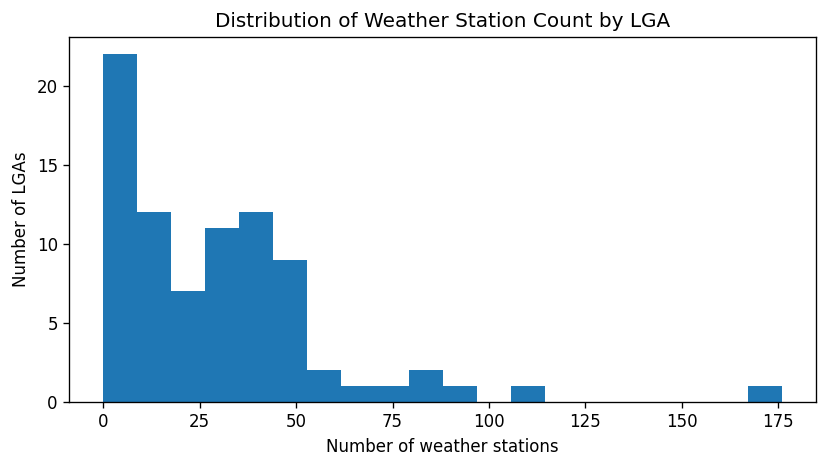

In [ ]:
hist_plot(
    "st_cnt",
    "Distribution of Weather Station Count by LGA",
    "Number of weather stations",
    "hist_station_count.png"
)

The histograms show that the variables are unevenly distributed. Agricultural value is likely to be right-skewed, with a small number of LGAs contributing much larger values than most others. Rainfall and elevation also vary across the state, reflecting the contrast between the drier north-west and the wetter south-east and upland regions.

## 11. ESDA: scatter plots and correlations

This cell checks the relationships between the main LGA-level variables.

In [ ]:
corr = g[["ag_val", "rain", "elev", "st_cnt"]].corr(method="pearson")
corr

,ag_val,rain,elev,st_cnt
ag_val,1.000000,-0.243883,-0.081276,0.569203
rain,-0.243883,1.000000,0.554988,0.165014
elev,-0.081276,0.554988,1.000000,0.408728
st_cnt,0.569203,0.165014,0.408728,1.000000


In [ ]:
key_names = [
    "Mildura", "Swan Hill", "Campaspe", "Moyne", "Corangamite",
    "East Gippsland", "Alpine", "Mansfield"
]

def label_points(ax, xcol, ycol):
    for nm in key_names:
        m = g["LGA_NAME21"].str.contains(nm, case=False, na=False)
        if m.any():
            r = g.loc[m].iloc[0]
            if pd.notna(r[xcol]) and pd.notna(r[ycol]):
                ax.annotate(
                    nm,
                    (r[xcol], r[ycol]),
                    fontsize=8,
                    xytext=(4, 4),
                    textcoords="offset points"
                )

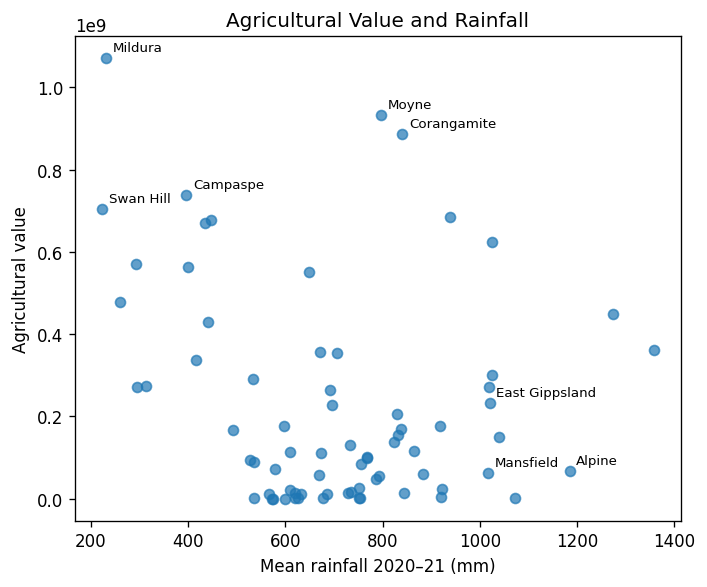

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(g["rain"], g["ag_val"], alpha=0.7)
label_points(ax, "rain", "ag_val")

ax.set_title("Agricultural Value and Rainfall")
ax.set_xlabel("Mean rainfall 2020–21 (mm)")
ax.set_ylabel("Agricultural value")

plt.tight_layout()
plt.savefig("scatter_ag_value_rainfall.png", dpi=300, bbox_inches="tight")
plt.show()

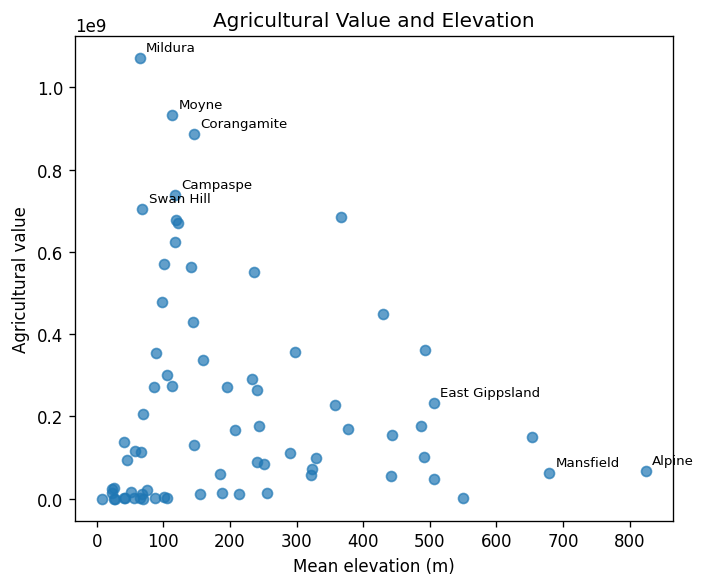

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(g["elev"], g["ag_val"], alpha=0.7)
label_points(ax, "elev", "ag_val")

ax.set_title("Agricultural Value and Elevation")
ax.set_xlabel("Mean elevation (m)")
ax.set_ylabel("Agricultural value")

plt.tight_layout()
plt.savefig("scatter_ag_value_elevation.png", dpi=300, bbox_inches="tight")
plt.show()

The scatter plots help explain why the final interpretation should not be too simple. For example, Mildura and Swan Hill are important agricultural LGAs in the drier north-west, so their agricultural value is not only related to high rainfall. In contrast, south-western LGAs such as Moyne and Corangamite may combine strong agricultural production with more temperate rainfall conditions. Higher elevation LGAs in the east and north-east, such as Alpine or Mansfield, show different terrain conditions and are less directly comparable to lowland farming regions.

## 12. ESDA maps

This section maps the spatial distribution of the main LGA-level variables. Quantile classes are used so that the spatial contrast between LGAs is easier to compare. The maps also include a north arrow and scale bar to improve cartographic presentation quality


In [ ]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

def north(ax):
    ax.annotate(
        "N",
        xy=(0.93, 0.90),
        xytext=(0.93, 0.80),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        arrowprops=dict(
            facecolor="black",
            edgecolor="black",
            width=3,
            headwidth=10
        )
    )

def scale_bar(ax, length=100000):
    fontprops = fm.FontProperties(size=9)

    bar = AnchoredSizeBar(
        ax.transData,
        length,
        f"{int(length / 1000)} km",
        "lower left",
        pad=0.4,
        color="black",
        frameon=False,
        size_vertical=3000,
        fontproperties=fontprops
    )

    ax.add_artist(bar)

def qmap(col, title, label, cmap, out_file):
    m = g.to_crs(7899).copy()

    fig, ax = plt.subplots(figsize=(9, 7.5))

    m.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        scheme="quantiles",
        k=5,
        legend=True,
        edgecolor="white",
        linewidth=0.35,
        missing_kwds={
            "color": "#d9d9d9",
            "label": "No data"
        },
        legend_kwds={
            "title": label,
            "loc": "lower right",
            "fontsize": 8,
            "title_fontsize": 9,
            "frameon": True,
            "fmt": "{:.0f}"
        }
    )

    m.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.2
    )

    north(ax)
    scale_bar(ax, 100000)

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_axis_off()

    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()

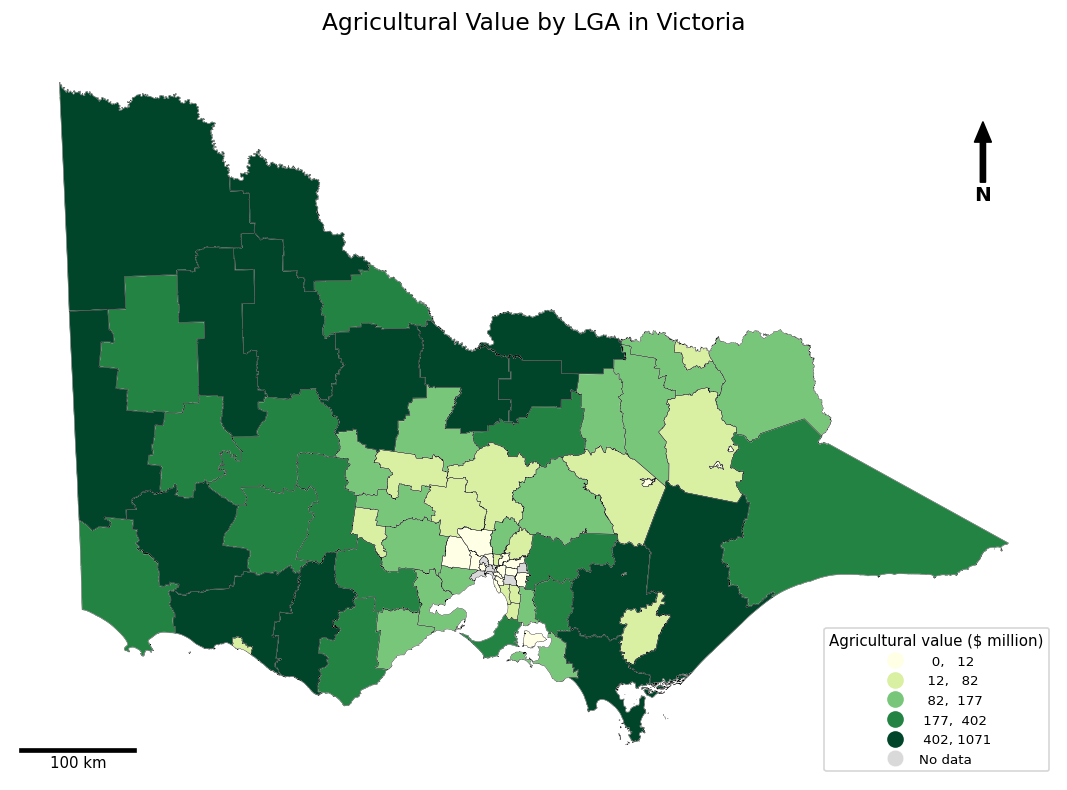

In [ ]:
qmap(
    "ag_val_m",
    "Agricultural Value by LGA in Victoria",
    "Agricultural value ($ million)",
    "YlGn",
    "map_agri_value_victoria.png"
)

The agricultural value map shows that agricultural production value is not evenly spread across Victoria. High-value areas are concentrated in regional agricultural LGAs rather than in metropolitan Melbourne. North-western LGAs such as Mildura and Swan Hill stand out because they have strong agricultural value despite being in a drier part of the state. South-western LGAs such as Moyne and Corangamite also appear important, reflecting the agricultural strength of temperate dairy and mixed farming regions.

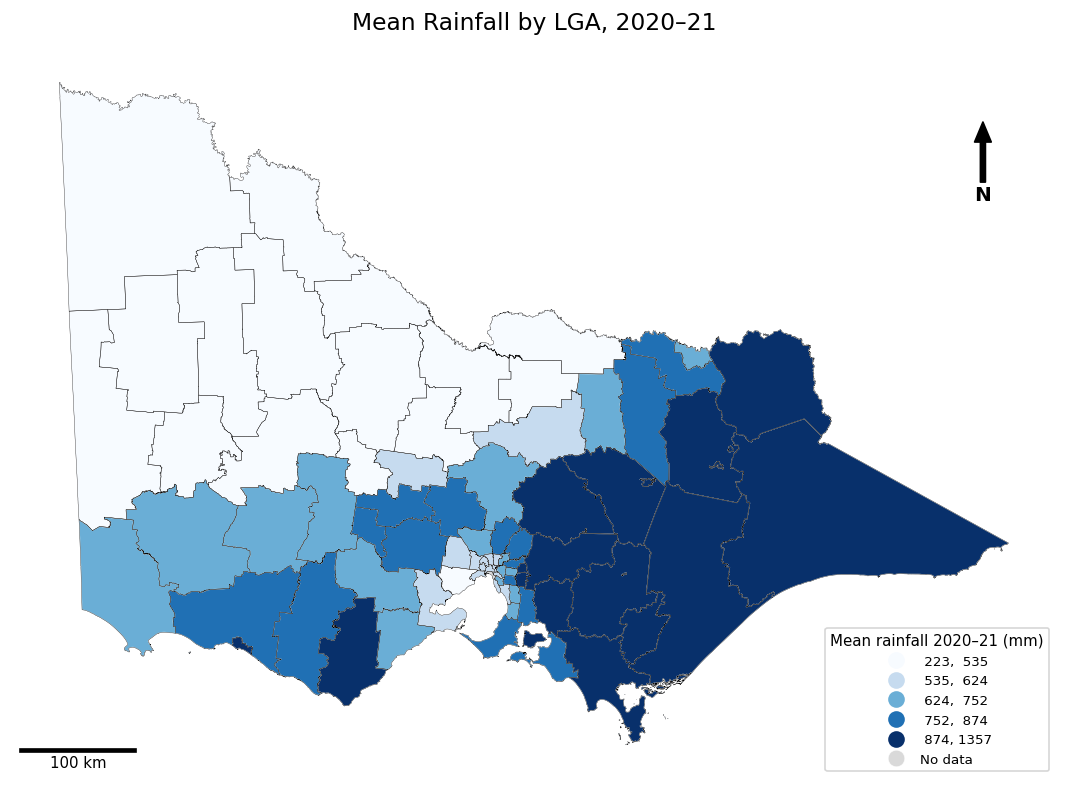

In [ ]:
qmap(
    "rain",
    "Mean Rainfall by LGA, 2020–21",
    "Mean rainfall 2020–21 (mm)",
    "Blues",
    "map_rain_lga_victoria.png"
)

The rainfall map shows a clear contrast between drier north-western Victoria and wetter southern, eastern and upland regions. Mildura and Swan Hill are located in the lower-rainfall north-west, while areas such as Yarra Ranges, Baw Baw, Alpine, South Gippsland and East Gippsland have higher rainfall. This spatial pattern is important because high agricultural value is not found only in the wettest LGAs.

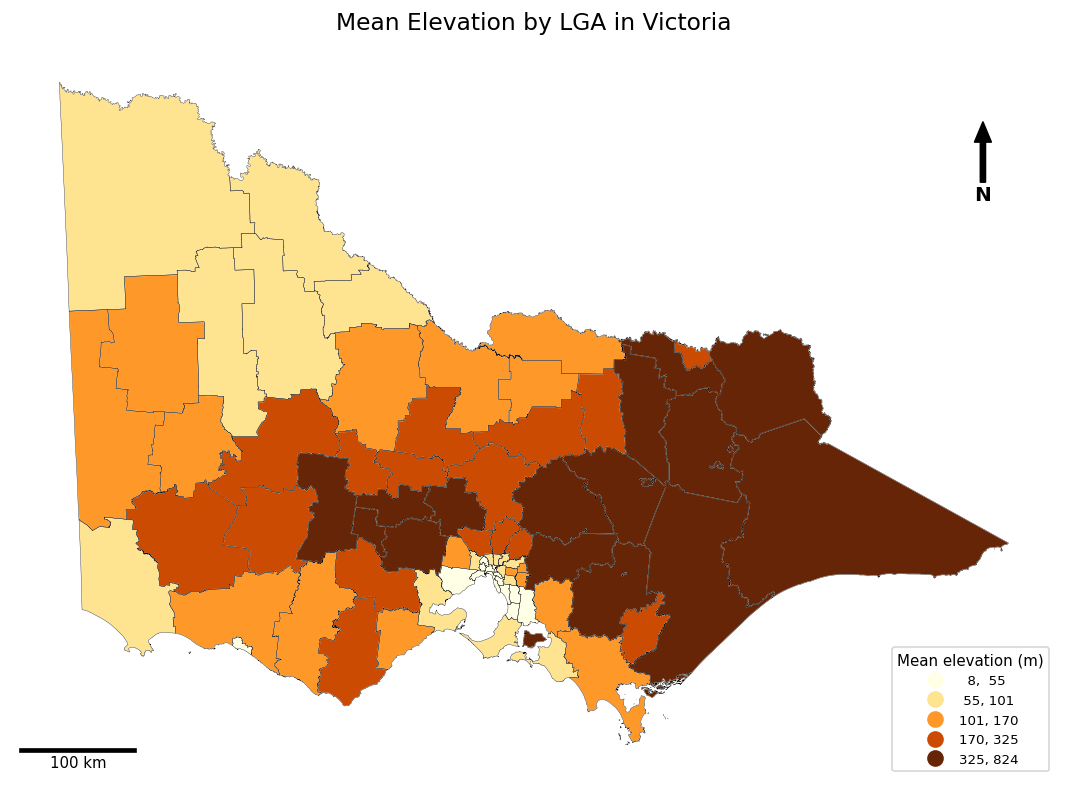

In [ ]:
qmap(
    "elev",
    "Mean Elevation by LGA in Victoria",
    "Mean elevation (m)",
    "YlOrBr",
    "map_elev_lga_victoria.png"
)

The elevation map shows higher land in eastern and north-eastern Victoria. Alpine and Mansfield are clear examples. The north-west and western plains are much lower. Elevation gives a simple view of terrain, but it is not the same as slope or soil quality. So it should only be used as background context, not as a direct reason for agricultural value.

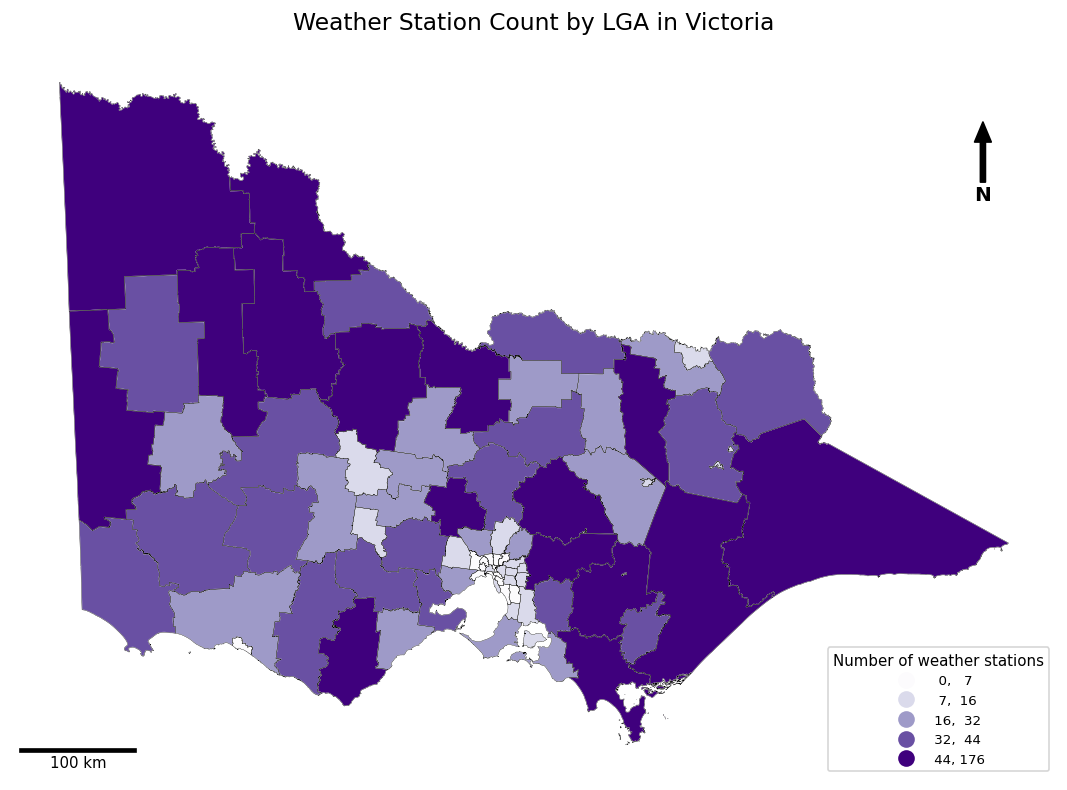

In [ ]:
qmap(
    "st_cnt",
    "Weather Station Count by LGA in Victoria",
    "Number of weather stations",
    "Purples",
    "map_station_count_lga_victoria.png"
)

The station count map displays the aggregate totals of the point data set by polygon, as well as reminds us of the differences in location of climatic observational infrastructure. However, station count will not be used as an explanation of agricultural value but as a means to depict the location of climatic data that was gathered within the study area.

## 13. Own analysis: LGA classification

This is the main analytical step after ESDA. It turns rainfall, elevation and agricultural value into interpretable LGA types

In [ ]:
g["group"] = "Other LGAs"

miss = g[["ag_val", "rain", "elev"]].isna().any(axis=1)
valid = ~miss

g.loc[miss, "group"] = "No data"

ag_cut = g.loc[valid, "ag_val"].quantile(0.75)
rain_mid = g.loc[valid, "rain"].quantile(0.50)
elev_cut = g.loc[valid, "elev"].quantile(0.75)

g.loc[
    valid &
    (g["ag_val"] >= ag_cut) &
    (g["rain"] >= rain_mid),
    "group"
] = "High value, higher rainfall"

g.loc[
    valid &
    (g["ag_val"] >= ag_cut) &
    (g["rain"] < rain_mid),
    "group"
] = "High value, lower rainfall"

g.loc[
    valid &
    (g["ag_val"] < ag_cut) &
    (g["elev"] >= elev_cut),
    "group"
] = "Lower value, higher elevation"

g["group"].value_counts(dropna=False)

group
Other LGAs                       39
Lower value, higher elevation    15
High value, lower rainfall       11
No data                          10
High value, higher rainfall       7
Name: count, dtype: int64

The classification uses relative thresholds within Victoria. High agricultural value is defined as the top 25% of LGAs by agricultural value. Higher rainfall is based on the median rainfall value, and higher elevation is based on the top 25% of mean elevation.

In [ ]:
group_tab = (
    g[g["group"] != "No data"]
    .groupby("group", as_index=False)
    .agg(
        lga_count=("LGA_NAME21", "count"),
        mean_ag_val=("ag_val", "mean"),
        mean_rain=("rain", "mean"),
        mean_elev=("elev", "mean"),
        mean_st_cnt=("st_cnt", "mean")
    )
    .sort_values("lga_count", ascending=False)
)

group_tab = group_tab.round({
    "mean_ag_val": 0,
    "mean_rain": 1,
    "mean_elev": 1,
    "mean_st_cnt": 1
})

group_tab

,group,lga_count,mean_ag_val,mean_rain,mean_elev,mean_st_cnt
3,Other LGAs,39,94061741.0,675.3,119.9,18.8
2,"Lower value, higher elevation",15,111774137.0,865.3,486.2,42.3
1,"High value, lower rainfall",11,619342851.0,404.0,137.2,51.8
0,"High value, higher rainfall",7,613269683.0,990.7,250.6,65.1


The table summarises the average conditions of each group. No data records are excluded from this table so that the group averages are easier to interpret.

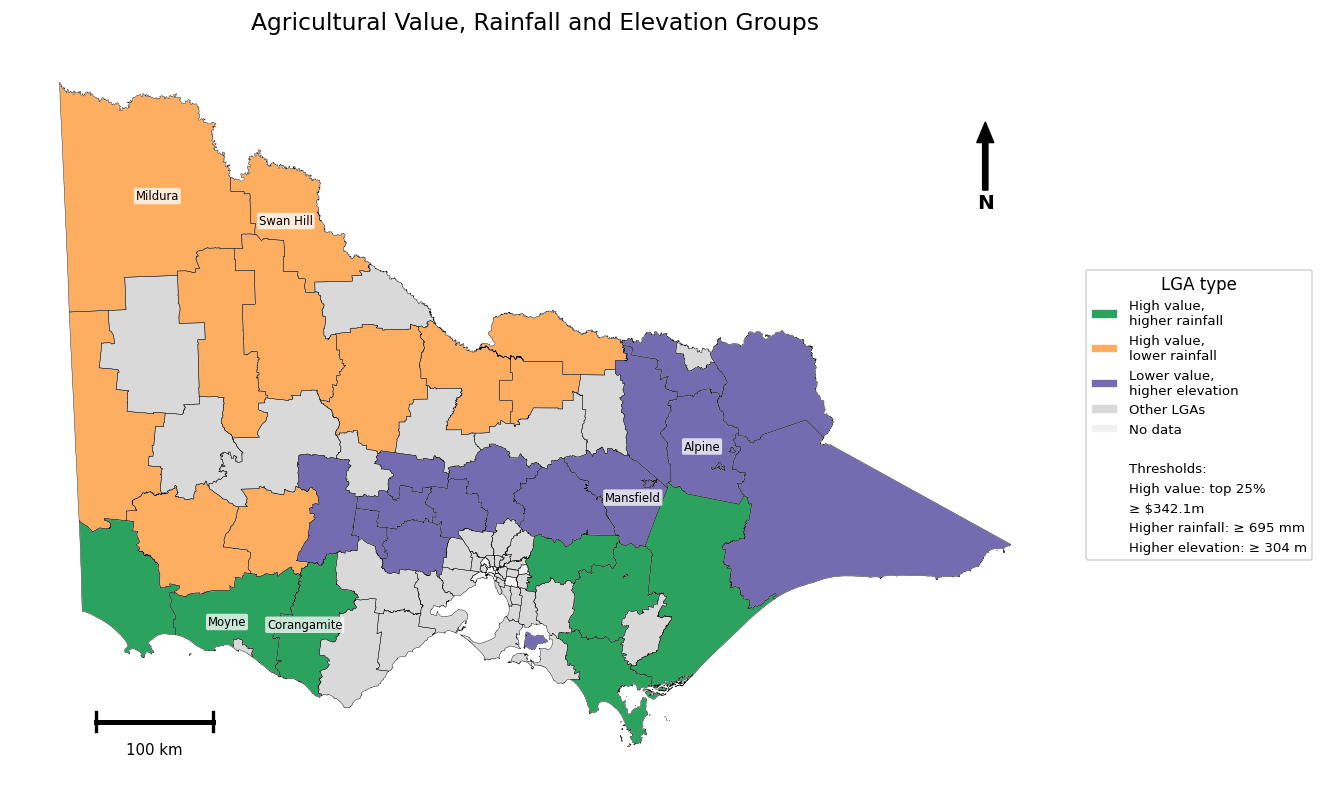

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

m = g.to_crs(7899).copy()

cols = {
    "High value, higher rainfall": "#2ca25f",
    "High value, lower rainfall": "#fdae61",
    "Lower value, higher elevation": "#756bb1",
    "Other LGAs": "#d9d9d9",
    "No data": "#f2f2f2"
}

m["map_col"] = m["group"].map(cols)

def north(ax):
    ax.annotate(
        "N",
        xy=(0.93, 0.90),
        xytext=(0.93, 0.79),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        arrowprops=dict(
            facecolor="black",
            edgecolor="black",
            width=3,
            headwidth=10
        )
    )

def scalebar(ax, length=100000):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    x = x0 + (x1 - x0) * 0.08
    y = y0 + (y1 - y0) * 0.08

    ax.plot([x, x + length], [y, y], color="black", linewidth=3)
    ax.plot([x, x], [y - 8000, y + 8000], color="black", linewidth=2)
    ax.plot([x + length, x + length], [y - 8000, y + 8000], color="black", linewidth=2)

    ax.text(
        x + length / 2,
        y - 18000,
        f"{int(length / 1000)} km",
        ha="center",
        va="top",
        fontsize=9
    )

fig, ax = plt.subplots(figsize=(11, 7.5))

m.plot(
    ax=ax,
    color=m["map_col"],
    edgecolor="white",
    linewidth=0.35
)

m.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.25
)

north(ax)
scalebar(ax, 100000)

m["lab_name"] = m["LGA_NAME21"].str.title()

labs = [
    "Mildura",
    "Swan Hill",
    "Moyne",
    "Corangamite",
    "Alpine",
    "Mansfield"
]

lab = m[m["lab_name"].isin(labs)].copy()
lab["pt"] = lab.geometry.representative_point()

for _, r in lab.iterrows():
    ax.text(
        r["pt"].x,
        r["pt"].y,
        r["lab_name"],
        fontsize=7,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            boxstyle="round,pad=0.15"
        )
    )

handles = [
    Patch(facecolor=cols["High value, higher rainfall"], edgecolor="white", label="High value,\nhigher rainfall"),
    Patch(facecolor=cols["High value, lower rainfall"], edgecolor="white", label="High value,\nlower rainfall"),
    Patch(facecolor=cols["Lower value, higher elevation"], edgecolor="white", label="Lower value,\nhigher elevation"),
    Patch(facecolor=cols["Other LGAs"], edgecolor="white", label="Other LGAs"),
    Patch(facecolor=cols["No data"], edgecolor="white", label="No data"),
    Line2D([], [], color="none", label=""),
    Line2D([], [], color="none", label="Thresholds:"),
    Line2D([], [], color="none", label=f"High value: top 25%"),
    Line2D([], [], color="none", label=f"≥ ${ag_cut/1e6:.1f}m"),
    Line2D([], [], color="none", label=f"Higher rainfall: ≥ {rain_mid:.0f} mm"),
    Line2D([], [], color="none", label=f"Higher elevation: ≥ {elev_cut:.0f} m")
]

ax.legend(
    handles=handles,
    title="LGA type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    title_fontsize=10,
    frameon=True
)

ax.set_title(
    "Agricultural Value, Rainfall and Elevation Groups",
    fontsize=14,
    pad=12
)

ax.set_axis_off()

plt.tight_layout()
plt.savefig("map_group_victoria.png", dpi=300, bbox_inches="tight")
plt.show()

The classification map shows that high agricultural value is not limited to one environmental setting. Some high-value LGAs are in the lower-rainfall north-west, such as Mildura and Swan Hill. Others are in the more temperate south-west, such as Moyne and Corangamite. Lower-value, higher-elevation LGAs are more common in eastern and north-eastern Victoria, including Alpine and Mansfield. This suggests that rainfall and elevation help explain the spatial pattern, but they are not enough to explain agricultural value alone.

## 14. High-value, lower-rainfall LGAs

This cell identifies LGAs where high agricultural value occurs under lower rainfall conditions.


In [ ]:
risk = (
    g[g["group"] == "High value, lower rainfall"]
    [["LGA_NAME21", "ag_val", "rain", "elev", "st_cnt"]]
    .sort_values("ag_val", ascending=False)
)

risk

,LGA_NAME21,ag_val,rain,elev,st_cnt
45,Mildura,1.071449e+09,230.969265,64.258415,88
11,Campaspe,7.385551e+08,396.375939,116.888298,46
66,Swan Hill,7.049376e+08,223.227043,67.832140,55
47,Moira,6.775808e+08,445.846084,118.410449,44
27,Greater Shepparton,6.712619e+08,433.969291,121.507111,30
78,Yarriambiack,5.701953e+08,293.282044,101.331786,50
37,Loddon,5.644964e+08,399.002940,141.688809,67
62,Southern Grampians,5.502611e+08,649.071028,236.507578,43
10,Buloke,4.783405e+08,260.143237,98.666970,59
71,West Wimmera,4.284001e+08,441.155651,144.409535,52


LGAs in this group may reflect irrigation, crop type, farm scale, regional specialisation or water management. This is especially relevant for the north-west of Victoria, where agricultural production can be high even when average rainfall is lower. The result should be interpreted as an association at LGA level, not as proof that rainfall has no effect.

## 15. Final analytical table

This cell creates the final table used for analysis and discussion.

In [ ]:
tab = g[
    [
        "LGA_CODE21",
        "LGA_NAME21",
        "ag_val",
        "rain",
        "elev",
        "st_cnt",
        "group"
    ]
].copy()

tab.to_csv("victoria_lga_agri_rain_elev.csv", index=False)

tab.head(10)

,LGA_CODE21,LGA_NAME21,ag_val,rain,elev,st_cnt,group
0,20110,Alpine,6.836209e+07,1184.700507,823.999012,36,"Lower value, higher elevation"
1,20260,Ararat,3.572935e+08,670.667261,298.013199,36,"High value, lower rainfall"
2,20570,Ballarat,5.513568e+07,792.400024,441.025255,13,"Lower value, higher elevation"
3,20660,Banyule,1.011204e+07,685.066650,67.558594,5,Other LGAs
4,20740,Bass Coast,1.164358e+08,864.776540,57.186072,17,Other LGAs
5,20830,Baw Baw,4.478974e+08,1273.489615,429.026335,84,"High value, higher rainfall"
6,20910,Bayside (Vic.),2.491055e+05,599.799988,26.308214,8,Other LGAs
7,21010,Benalla,1.114217e+08,672.398047,289.685200,31,Other LGAs
8,21110,Boroondara,1.313929e+06,676.300008,56.368925,15,Other LGAs
9,21180,Brimbank,3.464631e+05,535.766683,65.025244,6,Other LGAs


## Discussion

In general, agricultural output is unevenly distributed across the LGAs in Victoria. But you can’t describe this difference simply as “higher rainfall, higher ag output”. Rainfall and elevation provide some environmental context, but they can’t explain why some LGAs have higher ag output.

I think a key reason is that ag output isn’t just an environmental indicator – it’s an economic one. A region’s high ag output might be down to the cultivation of higher value crops, a more sophisticated irrigation system, a bigger arable land area, or connections to a stronger ag supply chain. This explains why some low-rainfall LGA regions like Mildura and Swan Hill still have high ag output – while they may lack natural rainfall, their irrigation techniques/water resources management/crop specialisation support efficient ag production.

But this also shows how there can be a flip side. If an arid region has high-value ag, then it will be heavily reliant on irrigation, making it potentially more vulnerable to drought, water constraints, and future climate change. High ag output doesn’t mean high resilience. Some regions might be economically vital, but environmentally vulnerable. So governments need to consider all this when developing long-term plans, and maintaining ag output in these regions may require sophisticated water resource management and climate change mitigation strategies.
On the other hand, the southwestern region of Victoria – with its higher rainfall and milder climate – also boasts high ag output. These areas may benefit from more consistent rainfall and mature ag systems, but aren’t without challenges, such as soil degradation, flood risk, land-use pressures, and the environmental impacts of intensive ag.

Of course, this study also has certain limitations. Since our analysis is based on total agricultural output at the LGA level, larger LGA areas or areas with more arable land may appear more important in the data, but this does not necessarily mean they have higher productivity per hectare. Future analyses could consider using agricultural output per hectare or comparing different crop types separately. Furthermore, average rainfall and elevation data at the LGA level may mask local differences within the region. Factors such as soil quality, irrigation conditions, land use patterns, slope, market prices, and transportation conditions were also not included in the analysis; therefore, the results of this study should not be considered direct evidence of causality.

## Sustainability and resilience recommendations

These results highlight some LGAs located in drier areas of Victoria that still offer high agricultural value despite lower rainfall. A feasible recommendation for these arid but high-agricultural-value areas is to prioritize their support, such as by improving water-saving irrigation systems, developing drought contingency plans, constructing farm water storage facilities, and encouraging the planting of water-reducing crops. In other words, identify LGAs that contribute significantly to agricultural value but also face low rainfall or higher climate stress. The key is to prioritize resources in areas where water scarcity would have a significant impact on the economy and food production.

Another recommendation is to improve monitoring at a finer spatial scale. Since LGA-level results can hide local differences, future sustainability planning should use more detailed land-use, soil, crop and irrigation data. This would help identify which parts of each LGA are most exposed to drought, erosion or declining soil condition. It would also allow more targeted support, rather than assuming that every farm within the same LGA faces the same level of risk.

For wetter or more temperate agricultural areas, resilience planning should be less about water scarcity and more about long-term land condition. They may need stronger soil conservation, nutrient management, flood preparedness and protecting native vegetation around farming land. In this way, sustainability is not just about keeping production high, but also about reducing the environmental pressure caused by intensive agriculture.

Overall, these recommendations relate to SDG 2 (sustainable food production), SDG 13 (climate change adaptation) and SDG 15 (more responsible land management). The key message is that different agricultural regions in Victoria can’t be managed the same way. Agricultural resilience planning needs to be tailored to local conditions, as the risks faced by arid but high value areas, wetter agricultural areas, and high-altitude areas are not the same.

## Conclusion

In conclusion, our project showed us that while rainfall and elevation help understand agricultural value in Victoria, they don’t tell the whole story. Some high-value areas occur in drier regions showing that irrigation, crop choice and regional specialisation are also important. Overall, our findings imply that agricultural planning should be based on local conditions rather than assuming that ‘the more rainfall, the better’.

## References

Australian Bureau of Statistics. (2021). Australian Statistical Geography Standard (ASGS) Edition 3: Digital boundary files. Australian Bureau of Statistics.

Australian Bureau of Statistics. (2022). Value of Agricultural Commodities Produced, Australia, 2020–21 financial year. Australian Bureau of Statistics.

Bureau of Meteorology. (n.d.). Climate Data Online. Australian Government.

Bureau of Meteorology, & CSIRO. (2024). State of the Climate 2024. Commonwealth of Australia.

Chancellor, W., Hughes, N., Zhao, S., Soh, W. Y., Valle, H., & Boult, C. (2021). Controlling for the effects of climate on total factor productivity: A case study of Australian farms. Food Policy, 102, Article 102091. https://doi.org/10.1016/j.foodpol.2021.102091

Department of Energy, Environment and Climate Action. (n.d.). Victorian Primary Production Landscapes (PPL) [Data set]. DataVic. https://doi.org/10.4226/92/58e72567b7d51

Geoscience Australia. (2025). Digital elevation data. Australian Government.

Hughes, N., Lawson, K., & Valle, H. (2017). Farm performance and climate: Climate-adjusted productivity for broadacre cropping farms (ABARES Research Report 17.4). Australian Bureau of Agricultural and Resource Economics and Sciences.

Hughes, N., Lu, M., Soh, W. Y., & Lawson, K. (2022). Modelling the effects of climate change on the profitability of Australian farms. Climatic Change, 172, Article 12. https://doi.org/10.1007/s10584-022-03356-5

Jeffrey, S. J., Carter, J. O., Moodie, K. B., & Beswick, A. R. (2001). Using spatial interpolation to construct a comprehensive archive of Australian climate data. Environmental Modelling & Software, 16(4), 309–330. https://doi.org/10.1016/S1364-8152(01)00008-1

SILO. (n.d.). SILO gridded climate data. Queensland Government.